# Test ispezione, raffinamento e marcatura

Workflow:
1. import del modulo;
2. inizializzazione ZED/robot;
3. ispezione globale;
4. raffinamento;
5. marcatura controllata;

## 1 — Import del modulo

Questa cella importa `inspection_and_marking.py`.

`importlib.reload(im)` serve per ricaricare il file `.py` se lo modifichi in VSCode durante la sessione notebook.

**Nota:** dopo `reload`, i parametri tornano ai valori scritti nel file `.py`, quindi la cella successiva li risetta per il tuning.

In [10]:
import importlib
import numpy as np
import time
import matplotlib.pyplot as plt

import inspection_and_marking as im
import Variables as vb

im = importlib.reload(im)

print("Modulo inspection_and_marking importato e ricaricato.")

Modulo inspection_and_marking importato e ricaricato.


## 2 — Inizializzazione robot + ZED

**Attenzione: muove il robot** verso la posizione iniziale.

In [11]:
# Se non hai già inizializzato la ZED nella cella precedente, lascia questa parte attiva.
if "zed" not in globals():
    zed, runtime, image_zed, point_cloud = im.init_zed()
    print("ZED inizializzata.")
else:
    print("ZED già inizializzata.")

ZED già inizializzata.


In [12]:
controller = im.RobotController(
    ip_address=im.IP_ROBOT,
    default_position_j=vb.LOOK_DOWN_POSITION_J_INIZIO
)

controller.connect()
print("Robot connesso.")

[14:49:45] INFO     Succesfully connected to robot Ethernet Slave and Modbus.                         techman.py:25

           INFO     Connected to Listen Node                                                          techman.py:37

Robot connesso.


In [13]:
# posizionamento iniziale
controller.default_positioning()
print("Robot in posizione iniziale.")

im.move_to_hub(controller)

Robot in posizione iniziale.
Ritorno alla posizione di hub [0, 0, 90].
  [CIRCLE] Movimento sferico: (1.9°, 124.6°) -> (0.0°, 90.0°)


In [14]:
# Switch per attivare/disattivare l'identificazione dei difetti generici
im.GENERIC_DETECTION = True

print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")

if im.GENERIC_DETECTION:
    print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")
    im.GLOBAL_ATTENTION_RADIUS = 400 # Tuning: con detection generica serve un po' di attenzione per evitare falsi positivi ai bordi.
else:
    print("Rilevamento generico dei difetti disattivato.")
    im.GLOBAL_ATTENTION_RADIUS = None

Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius
Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius


## 3 — Ispezione globale completa

**Attenzione: muove il robot.**

In [1]:
all_defects = []

INSPECTION_POSITIONS = [
    [im.INSPECTION_RADIUS,   0, 90],   # alto
    [im.INSPECTION_RADIUS,   0, 45],   # frontale/intermedio
    [im.INSPECTION_RADIUS,   0, 30],   # frontale/intermedio
    [im.INSPECTION_RADIUS,  87, 60],   # laterale destro
    [im.INSPECTION_RADIUS, -87, 60],   # laterale sinistro
]

# commenta se vuoi usare delle posizoni personalizzate, altrimenti usa quelle di default
# INSPECTION_POSITIONS = im.INSPECTION_POSITIONS

print("=== ISPEZIONE GLOBALE ===")
print(f"Numero posizioni di ispezione: {len(INSPECTION_POSITIONS)}")

im.move_to_hub(controller)

for i, inspection_position in enumerate(INSPECTION_POSITIONS):

    if input(f"\nPremi Invio per eseguire lo scatto in posizione {inspection_position}") != "":
        print("Scatto saltato.")
        continue

    print("\n" + "-" * 60)
    print(f"Scatto {i + 1}/{len(INSPECTION_POSITIONS)}")
    print(f"Posizione sferica: {inspection_position}")

    defect_list, debug_img, mask_bgr, bgr_image = im.point_and_shoot(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        test_sph=inspection_position,
        insp_radius=im.INSPECTION_RADIUS_FN,        # raggio variabile (apice ampio, lati/retro stretti)
        helmet_center=vb.HELMET_CENTER_GLOBAL
    )

    print(f"Difetti trovati in questo scatto: {len(defect_list)}")

    for idx, d in enumerate(defect_list):
        d.say_hi(Name=f"Scatto {i + 1} - difetto {idx + 1}")

    all_defects.extend(defect_list)

    im.show_debug_matplotlib(
        debug_img=debug_img,
        mask_bgr=mask_bgr,
        title=f"Scatto {i + 1}"
    )

print("\n=== ISPEZIONE COMPLETATA ===")
print(f"Difetti totali prima del filtro duplicati: {len(all_defects)}")

unique_defects = im.duplicate_filter(
    all_defects,
    distance_threshold=im.DUPLICATE_DISTANCE
)

print(f"Difetti univoci dopo filtro duplicati: {len(unique_defects)}")


for idx, d in enumerate(unique_defects):
    d.say_hi(Name=f"Difetto unico {idx + 1}")

print("\nRitorno all'hub...")
im.move_to_hub(controller)

NameError: name 'im' is not defined

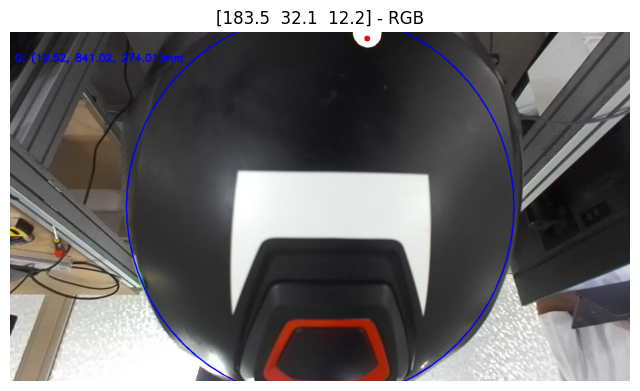

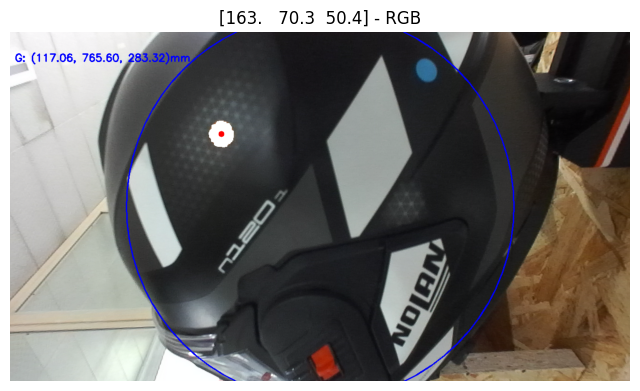

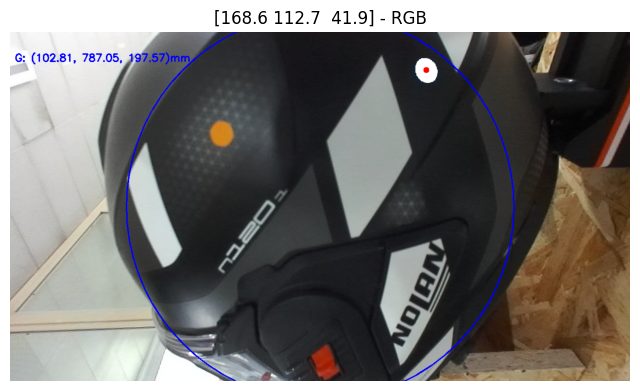

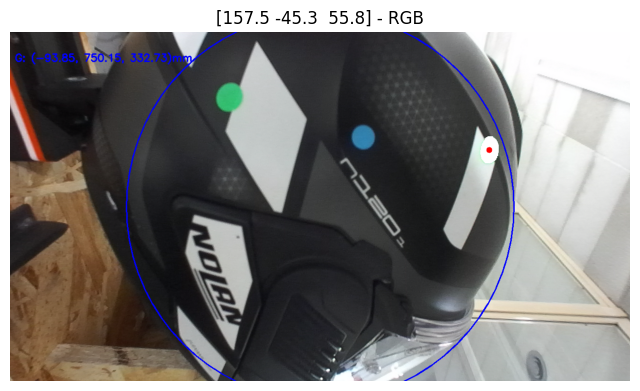

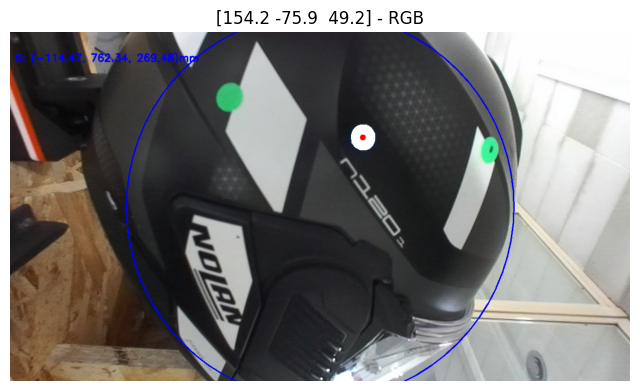

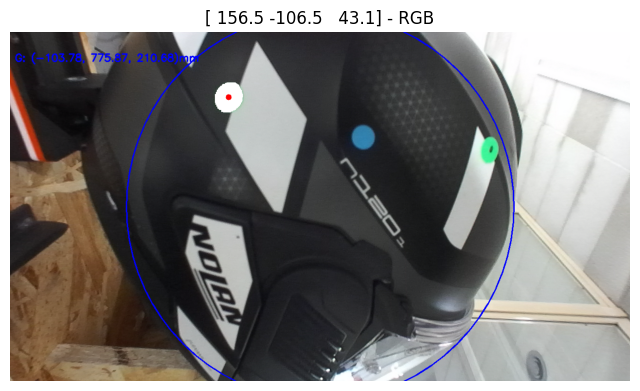

In [ ]:
if len(unique_defects) == 0:
    print("Nessun difetto univoco da visualizzare.")
else:
    n_defects = len(unique_defects)
    cols = min(4, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, unique_defects):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle("Tutti i difetti unici", fontsize=16)
    plt.tight_layout()
    plt.show()

## 4 — Raffinamento di ogni difetto

**Attenzione: muove il robot.**

In [ ]:
print("=== RAFFINAMENTO DI TUTTI I DIFETTI ===")
im.move_to_hub(controller)

refined_defects = []

print(f"Difetti da raffinare: {len(unique_defects)}")

for i, d in enumerate(unique_defects.copy()):  # Crea una copia per iterare

    print("\n" + "-" * 60)
    print(f"Raffinamento difetto {i + 1}/{len(unique_defects)}")

    d.say_hi(Name=f"Difetto {i + 1} prima del raffinamento")
    im.show_debug_matplotlib(d.img(), title=f"{np.round(d.sph_coord,1)}")

    if input(f"\nPremi Invio per il raffinamento in posizione {np.round(d.sph_coord, 2)}") != "":
        print("raffinamento saltato.")
        continue
    
    success = im.refine_defect_position(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        defect_obj=d,
        helmet_center=vb.HELMET_CENTER_GLOBAL,
        generic_detection=im.GENERIC_DETECTION
    )

    if success:
        print(f"Difetto {i + 1} raffinato correttamente.")
        d.say_hi(Name=f"Difetto {i + 1} raffinato")
        refined_defects.append(d)
    else:
        print(f"Difetto {i + 1} scartato/non confermato/irraggiungibile.")

print("\n=== RAFFINAMENTO COMPLETATO ===")
print(f"Difetti iniziali: {len(unique_defects)}")
print(f"Difetti raffinati/confermati: {len(refined_defects)}")

for i, d in enumerate(refined_defects):
    d.say_hi(Name=f"Difetto raffinato {i + 1}")

print("\nRitorno alla posizione iniziale...")
im.move_to_hub(controller)
print("Robot tornato in posizione iniziale.")

=== RAFFINAMENTO DI TUTTI I DIFETTI ===
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti da raffinare: 6

------------------------------------------------------------
Raffinamento difetto 1/6
      Difetto 1 prima del raffinamento rilevato:
        centroid: [737  13]
        pos3d_camera: [ 20.7 -61.2 128.2]
        Z camera: 128.2 mm
        radial camera: 64.6 mm
        pos3d_global: [ 19.5 841.  274. ]
        sph_coord [r, alpha, beta]: [183.5  32.1  12.2]
 Raffinamento difetto: r_stimato=183.5mm, alpha=32.1°, beta=12.2°
  [SKIP] Destinazione (alpha=32.1°, beta=12.2°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 1 scartato/non confermato/irraggiungibile.

------------------------------------------------------------
Raffinamento difetto 2/6
      Difetto 2 prima del raffinamento rilevato:
        centroid: [436 210]
        p

In [ ]:
print("=== VISUALIZZA TUTTI I DIFETTI RAFFINATI ===")
if len(refined_defects) == 0:
    print("Nessun difetto raffinato da visualizzare.")
else:
    n_defects = len(refined_defects)
    cols = min(4, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, refined_defects):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle("Tutti i difetti raffinati", fontsize=16)
    plt.tight_layout()
    plt.show()

## 5 — Marcatura di ogni difetto

**Attenzione: muove il robot e prova a marcare con il pennarello.**

In [ ]:
print("=== MARCATURA DI TUTTI I DIFETTI VALIDI ===")
im.move_to_hub(controller)

# Usa refined_defects se hai fatto la cella di raffinamento.
# Se invece vuoi marcare direttamente quelli dell'ispezione globale, cambia in unique_defects.
valid_defects = refined_defects

print(f"Difetti validi da marcare: {len(valid_defects)}")


marked_defects = []

if not input(f"Premi INVIO per marcare tutti i difetti validi, scrivi nope per annullare: ") == "nope":

    for i, d in enumerate(valid_defects):

        print("\n" + "-" * 60)
        print(f"Marcatura difetto {i + 1}/{len(valid_defects)}")
        d.say_hi(Name=f"Difetto {i + 1} da marcare")
        im.show_debug_matplotlib(d.img(), title=f"{np.round(d.sph_coord,1)}")


        if input(f"\nPremi Invio per marcare il difetto in posizione {np.round(d.sph_coord, 2)}") != "":
            print("Marcatura saltata.")
            continue

        success = im.mark_defect(
            controller=controller,
            defect_obj=d,
            helmet_center=vb.HELMET_CENTER_GLOBAL
        )

        if success:
            print(f"Difetto {i + 1} marcato correttamente.")
            marked_defects.append(d)
        else:
            print(f"Difetto {i + 1} non marcato.")

else:
    print("Marcatura annullata.")

print("\n=== MARCATURA COMPLETATA ===")
print(f"Difetti validi: {len(valid_defects)}")
print(f"Difetti marcati: {len(marked_defects)}")

print("\nRitorno alla posizione iniziale...")
im.move_to_hub(controller)
controller.default_positioning()
print("Robot tornato in posizione iniziale.")

=== MARCATURA DI TUTTI I DIFETTI VALIDI ===
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti validi da marcare: 3

------------------------------------------------------------
Marcatura difetto 1/3
      Difetto 1 da marcare rilevato:
        centroid: [436 210]
        pos3d_camera: [-36.  -29.9 143.9]
        Z camera: 143.9 mm
        radial camera: 46.8 mm
        pos3d_global: [115.4 766.8 286.2]
        sph_coord [r, alpha, beta]: [163.   70.3  50.4]
  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (70.3°, 50.4°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [115.4 766.8 286.2] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [281.8 910.4 341.9 105.4 -12.4 -52. ]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 1 marcato correttamente.

------------------------------------------------